# Haplosaurus

In [10]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/grid/koo/home/schilder/projects/GenomeEncoder/')
import pandas as pd
import src.haplosaurus as hs
import src.variant_annotation as va
import src.ESM as ESM
import src.predict_esm as ESMp
import src.onekg as onekg
import src.utils as utils
import src.gprofiler as gp
# import src.proteingym as pg
from src.config import DATA_DIR
from src.haplosaurus  import DIR_DICT

import sys
sys.path.append('ProteinGym')
import proteingym.utils.download as pgd # Local version

pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Get transcripts

In [ ]:
# Haplosaurus protein IDs
tx_df = pd.read_excel(DATA_DIR + "haplosaurus/41467_2018_6542_MOESM4_ESM.xlsx")
print(tx_df.shape)
# Bioconductor transcript to protein ID
tx_to_prot = pd.read_csv(DATA_DIR + "bioc/bioc_tx_to_prot.csv.gz")
print(tx_to_prot.shape)
tx_df = tx_df.merge(tx_to_prot.drop_duplicates(subset=['tx_id', 'protein_id']),
                    left_on="Ensembl Protein ID", 
                    right_on="protein_id", 
                    how="inner") 
print(tx_df.shape)
tx_df.head()

(20166, 6)
(109705, 9)
(18494, 15)


/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3098: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Ensembl Gene ID,Ensembl Protein ID,Gene Name,Number of Haplotypes,Number of Haplotypes FoO>=1%,Frequency Rank of Reference Protein Haplotype,seqnames,start,end,width,strand,protein_id,uniprot_id,tx_biotype,tx_id
0,ENSG00000121410,ENSP00000263100,A1BG,44,3.0,2.0,19,58346850,58353499,6650,-,ENSP00000263100,P04217,protein_coding,ENST00000263100
1,ENSG00000148584,ENSP00000363107,A1CF,25,2.0,1.0,10,50806562,50885675,79114,-,ENSP00000363107,Q9NQ94,protein_coding,ENST00000373995
2,ENSG00000175899,ENSP00000323929,A2M,69,5.0,10.0,12,9067712,9116157,48446,-,ENSP00000323929,P01023,protein_coding,ENST00000318602
3,ENSG00000166535,ENSP00000299698,A2ML1,171,9.0,10.0,12,8822472,8876785,54314,+,ENSP00000299698,A8K2U0,protein_coding,ENST00000299698
4,ENSG00000184389,ENSP00000475261,A3GALT2,34,1.0,1.0,1,33306766,33321098,14333,-,ENSP00000475261,U3KPV4,protein_coding,ENST00000442999


<AxesSubplot:>

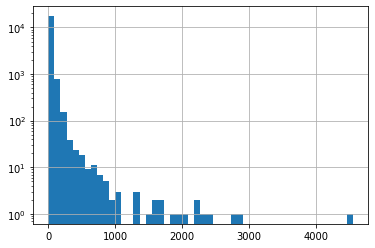

In [8]:
tx_df['Number of Haplotypes'].hist(bins=50, log=True)

In [9]:
# Remove MUC genes with lots of haplotypes as these may be artifacts
# tx_df = tx_df[(tx_df['Number of Haplotypes'] > 50) & (tx_df['Number of Haplotypes'] < 1000)]
# tx_df['Gene Name'].str.startswith('MUC')
tx_df.sort_values('Number of Haplotypes', ascending=False)
tx_ids = list(set(tx_df['tx_id'].tolist()))
tx_ids.reverse() # Start with the smallest number of haplotypes
# tx_ids = tx_ids[:5]

print(len(tx_ids),"transcripts")

18494 transcripts


## Get variant sets
Collect sets of variants (pathogenic, benign, 1KG) for each transcripts. 
Only trancripts with at least one pathogenic variant and one benign variant of the specifiied consequence type are included. Pathogenic/benign variants present in the 1KG cohort are excluded.

### Missense

In [10]:
variant_sets_dict = {
    ('SO:0001583','missense_variant'):{},
    ('SO:0001589','frameshift_variant'):{},
    ('SO:0001906','feature_truncation'):{}
    }

In [ ]:
for so_term, consequence_type in variant_sets_dict.keys():
    print(so_term, consequence_type)
    # Gather variant sets
    variant_sets_dict[(so_term, consequence_type)] = hs.get_variant_sets(
        tx_ids = tx_ids,
        so_term = so_term,
        consequence_type = consequence_type,
        # cache_only = cache_only, # Use cached files only (faster)
        error=False,
        # force=True
        )


In [21]:
# Get the number of transcripts with variant sets per consequence type
{k:len(v) for k,v in variant_sets_dict.items()}

{('SO:0001583', 'missense_variant'): 1070,
 ('SO:0001589', 'frameshift_variant'): 0,
 ('SO:0001906', 'feature_truncation'): 0}

## Get haplotypes


In [46]:
haplotypes = hs.get_haplotypes(
#     tx_ids=tx_ids, #variant_sets.keys(),
    cache_only=True, # Use cached files only (faster)
    use_protein_ids=True,
    force=False
    )


Found 403 haplotypes in /grid/koo/home/schilder/projects/data/haplosaurus/haplotypes/


Getting haplotypes:   0%|          | 0/403 [00:00<?, ?it/s]

  0%|          | 0/403 [00:00<?, ?it/s]

In [50]:
haplotypes['ENSP00000454071']['protein_haplotypes'].__len__()

56

## Get reference haplotypes

In [15]:
haplotypes_ref = hs.get_haplotype_ref(haplotypes)
haplotypes_ref_seqs, missing_seqs = hs.get_haplotype_seqs(
    haplotypes_ref,
    return_missing=True,
    verbose=True)
(len(haplotypes), 
 len(haplotypes_ref), 
 len(haplotypes_ref_seqs),
 len(missing_seqs))


Processing transcripts:   0%|          | 0/402 [00:00<?, ?it/s]

  0%|          | 0/402 [00:00<?, ?it/s]

No seqs found for ENST00000359568
No seqs found for ENST00000324093
No seqs found for ENST00000405460
No seqs found for ENST00000354785


(402, 402, 398, 4)

## Add variants to haplotypes

In [ ]:
haplotypes_wt, haplotypes_pathogenic, haplotypes_benign = hs.add_variant_to_haplotypes(
  haplotypes=haplotypes, 
  variant_sets=variant_sets, 
  tx_ids=tx_ids,
  consequence_terms=['missense_variant'],
  max_transcripts=5,
  ref_checks=False,
  verbose=True
  )
# check length of each group
len(haplotypes_wt), len(haplotypes_pathogenic), len(haplotypes_benign)

In [17]:
print(hs.get_haplotype_counts(haplotypes_wt))
print(hs.get_haplotype_counts(haplotypes_pathogenic))
print(hs.get_haplotype_counts(haplotypes_benign))


{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}
{'ENST00000544455': 228, 'ENST00000220676': 122, 'ENST00000392403': 92, 'ENST00000300589': 105, 'ENST00000373818': 57}


# Explore VEP results

In [3]:
# Gather additional PGD metadata
resources_df = pgd.get_resources_df()
pgd_resources = pgd.download_resources(resources_df.loc[resources_df['Filename'].isin(['substitutions_raw_clinical.zip', 'indels_raw_clinical.zip'])], 
                                       include_raw=True)

pgd_subs_raw = pd.read_csv(pgd_resources['substitutions_raw_clinical'][0])
print(pgd_subs_raw.groupby('clinsig')['HGVSp'].nunique())
pgd_subs_raw


clinsig
benign           21118
likely_benign    39054
likely_path      22760
path             10892
Name: HGVSp, dtype: int64


/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3098: DtypeWarning: Columns (0,47) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,protein,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,mutant,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,1,930204,1170208,G,A,.,PASS,1170208,1:930204,A,148398,NM_152486.4,Transcript,missense_variant,212,122,41,R/Q,cGg/cAg,-,MODERATE,-,1,-,-,-,G,G,-,NM_152486.4:c.122G>A,NP_689699.3:p.Arg41Gln,-,NP_689699.3,NaN,NaN,1153702,MedGen:CN517202,not_provided,NC_000001.11:g.930204G>A,"criteria_provided,_single_submitter",Benign,NaN,single_nucleotide_variant,SO:0001483,SAMD11:148398,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,R41Q,NaN,NaN,-2.373728,0.001126,2,benign
1,1,930245,1131472,G,A,.,PASS,1131472,1:930245,A,148398,NM_152486.4,Transcript,missense_variant,253,163,55,D/N,Gat/Aat,-,MODERATE,-,1,-,-,-,G,G,-,NM_152486.4:c.163G>A,NP_689699.3:p.Asp55Asn,-,NP_689699.3,NaN,NaN,1110866,MedGen:CN517202,not_provided,NC_000001.11:g.930245G>A,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,SAMD11:148398,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,D55N,NaN,NaN,-3.156072,-0.005246,2,likely_benign
2,1,930248,789256,G,A,.,PASS,789256,1:930248,A,148398,NM_152486.4,Transcript,missense_variant,256,166,56,G/S,Ggt/Agt,-,MODERATE,-,1,-,-,-,G,G,-,NM_152486.4:c.166G>A,NP_689699.3:p.Gly56Ser,-,NP_689699.3,0.00347,0.00622,707587,MedGen:CN517202,not_provided,NC_000001.11:g.930248G>A,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,SAMD11:148398,SO:0001583|missense_variant,1,41285790,0.0028,NaN,NaN,NaN,NaN,G56S,NaN,NaN,0.422027,0.002243,2,likely_benign
3,1,930282,1140293,G,A,.,PASS,1140293,1:930282,A,148398,NM_152486.4,Transcript,missense_variant,290,200,67,R/Q,cGg/cAg,-,MODERATE,-,1,-,-,-,G,G,-,NM_152486.4:c.200G>A,NP_689699.3:p.Arg67Gln,-,NP_689699.3,NaN,NaN,1110867,MedGen:CN517202,not_provided,NC_000001.11:g.930282G>A,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,SAMD11:148398,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,R67Q,NaN,NaN,-0.055703,-0.000809,2,likely_benign
4,1,930285,1165489,G,A,.,PASS,1165489,1:930285,A,148398,NM_152486.4,Transcript,missense_variant,293,203,68,R/Q,cGg/cAg,-,MODERATE,-,1,-,-,-,G,G,-,NM_152486.4:c.203G>A,NP_689699.3:p.Arg68Gln,-,NP_689699.3,NaN,NaN,1153703,MedGen:CN517202,not_provided,NC_000001.11:g.930285G>A,"criteria_provided,_single_submitter",Benign,NaN,single_nucleotide_variant,SO:0001483,SAMD11:148398,SO:0001583|missense_variant,1,NaN,NaN,NaN,NaN,NaN,NaN,R68Q,NaN,NaN,-0.513620,0.000148,2,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94158,Y,2787377,393470,C,A,.,PASS,393470,Y:2787377,A,6736,NM_003140.3,Transcript,missense_variant,306,227,76,R/L,cGc/cTc,-,MODERATE,-,-1,-,-,-,C,C,-,NM_003140.3:c.227G>T,NP_003131.1:p.Arg76Leu,-,NP_003131.1,NaN,NaN,380292,"MONDO:MONDO:0020712,MedGen:C2748896,OMIM:40004...","46,XY_sex_reversal_1",NC_000024.10:g.2787377C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,SRY:6736,SO:0001583|missense_variant,8,1057519627.0,NaN,ClinGen:CA16609283,NaN,NaN,NaN,R76L,-7.545611,-6.044751,-6.796988,-0.071817,9,likely_path
94159,Y,2787392,1470948,G,T,.,PASS,1470948,Y:2787392,T,6736,NM_003140.3,Transcript,missense_variant,291,212,71,S/Y,tCt/tAt,-,MODERATE,-,-1,-,-,-,G,G,-,NM_003140.3:c.212C>A,NP_003131.1:p.Ser71Tyr,-,NP_003131.1,NaN,NaN,1395175,"MONDO:MO

In [4]:
esm_vep = ESM.merge_vep("~/projects/data/1KG/vep")
esm_vep = gp.map_ids(esm_vep, 
                     rows_per_id=1, 
                     target_namespace='ENST')
esm_vep['protein_sequence_length'] = esm_vep['protein_sequence'].map(ESMp.preprocess_sequence).str.len()
esm_vep['mutated_sequence_length'] = esm_vep['mutated_sequence'].map(ESMp.preprocess_sequence).str.len()
# Annotate with PGD variants
esm_vep = esm_vep.merge(pgd_subs_raw.groupby(['protein', 'mutant']).head(1), on=['protein', 'mutant'], how='inner')
esm_vep

Found 198 wt-marginals files


Reading files: 100%|██████████| 198/198 [00:00<00:00, 211.26it/s]


Found 198 masked-marginals files


Reading files: 100%|██████████| 198/198 [00:00<00:00, 208.84it/s]


Found 196 pseudo-ppl files


Reading files: 100%|██████████| 196/196 [00:00<00:00, 209.82it/s]


Running gprofiler.convert with 5 queries.


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,esm1v_t33_650M_UR90S_1,scoring_strategy,is_ref,model_location,variant_set,mutant_in_haplotype,ENST,HGNC,protein_sequence_length,mutated_sequence_length,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000454071:REF,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-5.125133,wt-marginals,True,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions,False,ENST00000252444,LDLR,860,860,19,11089576,250975,T,A,.,PASS,250975,19:11089576,A,3949,NM_000527.5,Transcript,missense_variant,114,28,10,W/R,Tgg/Agg,-,MODERATE,-,1,-,-,-,T,T,-,NM_000527.5:c.28T>A,NP_000518.1:p.Trp10Arg,-,NaN,NaN,245340,"MONDO:MONDO:0007750,MedGen:C0745103,OMIM:14389...","Hypercholesterolemia,_familial,_1",NC_000019.10:g.11089576T>A,"criteria_provided,_multiple_submitters,_no_con...",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,LDLR:3949|LDLR-AS1:115271120,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,879254386.0,NaN,"ClinGen:CA10584725|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-2.108518,-0.002561,7,likely_path
1,ENSP00000454071:REF,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-2.082545,masked-marginals,True,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions,False,ENST00000252444,LDLR,860,860,19,11089576,250975,T,A,.,PASS,250975,19:11089576,A,3949,NM_000527.5,Transcript,missense_variant,114,28,10,W/R,Tgg/Agg,-,MODERATE,-,1,-,-,-,T,T,-,NM_000527.5:c.28T>A,NP_000518.1:p.Trp10Arg,-,NaN,NaN,245340,"MONDO:MONDO:0007750,MedGen:C0745103,OMIM:14389...","Hypercholesterolemia,_familial,_1",NC_000019.10:g.11089576T>A,"criteria_provided,_multiple_submitters,_no_con...",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,LDLR:3949|LDLR-AS1:115271120,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,879254386.0,NaN,"ClinGen:CA10584725|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-2.108518,-0.002561,7,likely_path
2,ENSP00000454071:REF,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15P,MGPWGWKLRWTVALPLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-8.496380,wt-marginals,True,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions,False,ENST00000252444,LDLR,860,860,19,11089592,250981,T,C,.,PASS,250981,19:11089592,C,3949,NM_000527.5,Transcript,missense_variant,130,44,15,L/P,cTc/cCc,-,MODERATE,-,1,-,-,-,T,T,-,NM_000527.5:c.44T>C,NP_000518.1:p.Leu15Pro,-,NaN,NaN,245347,"MONDO:MONDO:0005439,MedGen:C0020445,OMIM:PS143...",Familial_hypercholesterolemia|not_provided|Hyp...,NC_000019.10:g.11089592T>C,reviewed_by_expert_panel,Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,LDLR:3949|LDLR-AS1:115271120,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,879254390.0,NaN,"ClinGen:CA10584732|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-6.361703,-0.008103,7,likely_path
3,ENSP00000454071:REF,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15P,MGPWGWKLRWTVALPLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-5.408303,masked-marginals,True,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions,False,ENST00000252444,LDLR,860,860,19,11089592,250981,T,C,.,PASS,250981,19:11089592,C,3949,NM_000527.5,Transcript,missense_variant,130,44,15,L/P,cTc/cCc,-,MODERATE,-,1,-,-,-,T,T,-,NM_000527.5:c.44T>C,NP_000518.1:p.Leu15Pro,-,NaN,NaN,245347,"MONDO:MONDO:0005439,MedGen:C0020445,OMIM:PS143

In [5]:
esm_vep['clinsig'].value_counts()

likely_path      2833
likely_benign    2390
path             1274
benign           1051
Name: clinsig, dtype: int64

In [6]:
print(len(esm_vep.loc[esm_vep['protein_sequence_length'] != esm_vep['mutated_sequence_length']]),"rows with mismatched sequence lengths")
print(len(esm_vep.loc[esm_vep['protein_sequence'] == esm_vep['mutated_sequence']]),"rows with identical sequences")
print(esm_vep['mutant_in_haplotype'].sum(),"rows where the mutant was already in the haplotype")


0 rows with mismatched sequence lengths
0 rows with identical sequences
201 rows where the mutant was already in the haplotype


In [8]:
haplotypes = hs.get_haplotypes(
    cache_only=True 
    ) 
esm_vep['protein_id'] = esm_vep['haplotype'].str.split(':').str[0]
esm_vep = hs.add_haplotype_freqs(esm_vep, haplotypes, haplotype_col="haplotype")
esm_vep.head() 

Found 530 haplotypes in /grid/koo/home/schilder/projects/data/haplosaurus/haplotypes/


Getting haplotypes:   0%|          | 0/530 [00:00<?, ?it/s]

Adding tx_id column


Getting haplotype frequencies:   0%|          | 0/530 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations


Adding haplotype frequencies:   0%|          | 0/32 [00:00<?, ?it/s]

{'GBR': 'EUR', 'FIN': 'EUR', 'CHS': 'EAS', 'PUR': 'AMR', 'CDX': 'EAS', 'CLM': 'AMR', 'IBS': 'EUR', 'PEL': 'AMR', 'PJL': 'SAS', 'KHV': 'EAS', 'ACB': 'AFR', 'GWD': 'AFR', 'ESN': 'AFR', 'BEB': 'SAS', 'MSL': 'AFR', 'STU': 'SAS', 'ITU': 'SAS', 'CEU': 'EUR', 'YRI': 'AFR', 'CHB': 'EAS', 'JPT': 'EAS', 'LWK': 'AFR', 'ASW': 'AFR', 'MXL': 'AMR', 'TSI': 'EUR', 'GIH': 'SAS'}


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,esm1v_t33_650M_UR90S_1,scoring_strategy,is_ref,model_location,variant_set,mutant_in_haplotype,ENST,HGNC,protein_sequence_length,mutated_sequence_length,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,protein_id,tx_id,freq_1000GENOMES:phase_3:ACB,freq_1000GENOMES:phase_3:AFR,freq_1000GENOMES:phase_3:ALL,freq_1000GENOMES:phase_3:AMR,freq_1000GENOMES:phase_3:ASW,freq_1000GENOMES:phase_3:BEB,freq_1000GENOMES:phase_3:CDX,freq_1000GENOMES:phase_3:CEU,freq_1000GENOMES:phase_3:CHB,freq_1000GENOMES:phase_3:CHS,freq_1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:EAS,freq_1000GENOMES:phase_3:ESN,freq_1000GENOMES:phase_3:EUR,freq_1000GENOMES:phase_3:FIN,freq_1000GENOMES:phase_3:GBR,freq_1000GENOMES:phase_3:GIH,freq_1000GENOMES:phase_3:GWD,freq_1000GENOMES:phase_3:IBS,freq_1000GENOMES:phase_3:ITU,freq_1000GENOMES:phase_3:JPT,freq_1000GENOMES:phase_3:KHV,freq_1000GENOMES:phase_3:LWK,freq_1000GENOMES:phase_3:MSL,freq_1000GENOMES:phase_3:MXL,freq_1000GENOMES:phase_3:PEL,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:SAS,freq_1000GENOMES:phase_3:STU,freq_1000GENOMES:phase_3:TSI,freq_1000GENOMES:phase_3:YRI,top_pop,top_superpop
0,ENSP00000454071:REF,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-5.125133,wt-marginals,True,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions,False,ENST00000252444,LDLR,860,860,19,11089576,250975,T,A,.,PASS,250975,19:11089576,A,3949,NM_000527.5,Transcript,missense_variant,114,28,10,W/R,Tgg/Agg,-,MODERATE,-,1,-,-,-,T,T,-,NM_000527.5:c.28T>A,NP_000518.1:p.Trp10Arg,-,NaN,NaN,245340,"MONDO:MONDO:0007750,MedGen:C0745103,OMIM:14389...","Hypercholesterolemia,_familial,_1",NC_000019.10:g.11089576T>A,"criteria_provided,_multiple_submitters,_no_con...",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,LDLR:3949|LDLR-AS1:115271120,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,879254386.0,NaN,"ClinGen:CA10584725|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-2.108518,-0.002561,7,likely_path,ENSP00000454071,ENST00000558518,0.791667,0.773828,0.915335,0.942363,0.770492,0.988372,0.978495,0.924242,1.0,0.990476,0.904255,0.986111,0.792929,0.939364,0.959596,0.945055,0.990291,0.787611,0.920561,0.990196,0.975962,0.984848,0.742424,0.764706,0.976562,0.982353,0.994792,0.923077,0.989775,0.985294,0.948598,0.763889,1000GENOMES:phase_3:CHB,EAS
1,ENSP00000454071:REF,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-2.082545,masked-marginals,True,esm1v_t33_650M_UR90S_1,clinical_ProteinGym_substitutions,False,ENST00000252444,LDLR,860,860,19,11089576,250975,T,A,.,PASS,250975,19:11089576,A,3949,NM_000527.5,Transcript,missense_variant,114,28,10,W/R,Tgg/Agg,-,MODERATE,-,1,-,-,-,T,T,-,NM_000527.5:c.28T>A,NP_000518.1:p.Trp10Arg,-,NaN,NaN,245340,"MONDO:MONDO:0007750,MedGen:C0745103,OMIM:14389...","Hypercholesterolemia,_familial,_1",NC_000019.10:g.11089576T>A,"criteria_provided,_multiple_submitters,_no_con...",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,LDLR:3949|LDLR-AS1:115271120,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,879254386.0,NaN,"ClinGen:CA10584725|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-2.108518,-0.002561,7,likely_path,ENSP00000454071,ENST00000558518,0.791667,0.773828,0.915335,0.942363,0.770492,0.988372,0.978495,0.924242,1.0,0.

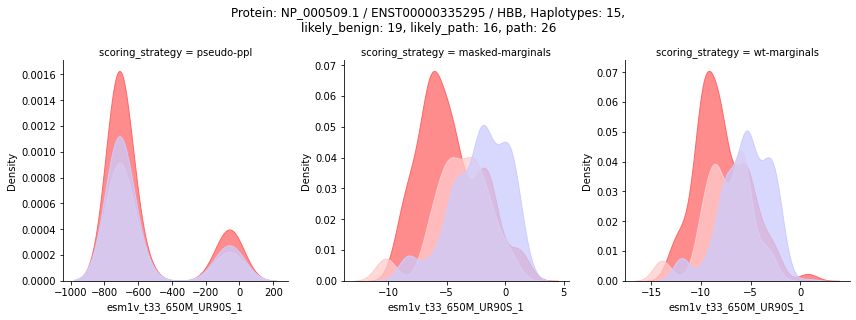

In [12]:
np_id='NP_000509.1'

ESM.plot_vep_density( esm_vep[esm_vep['protein'] == np_id])

<AxesSubplot:xlabel='clinsig', ylabel='esm1v_t33_650M_UR90S_1'>

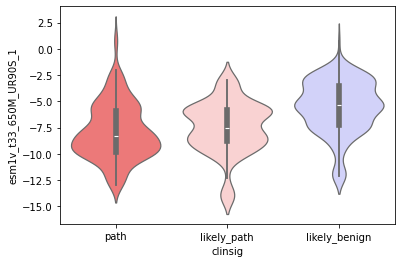

In [20]:
import seaborn as sns
sns.violinplot(data=esm_vep.loc[(esm_vep['protein'] == np_id) & (esm_vep['scoring_strategy'] == "wt-marginals")], 
                x='clinsig', y="esm1v_t33_650M_UR90S_1",
                hue='clinsig',
                palette=utils.get_clinsig_palette(),
                legend=False,
                 alpha=1)

Removed 164 rows with NA values in esm1v_t33_650M_UR90S_1


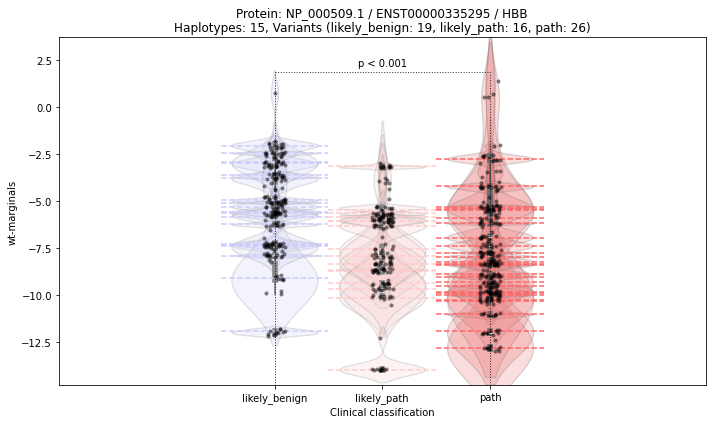

In [ ]:
ESM.plot_vep_violin(esm_vep.loc[(esm_vep['protein'] == np_id) & (esm_vep['scoring_strategy'] == "wt-marginals")], 
                    model_location="esm1v_t33_650M_UR90S_1",
                    # freq_filters = {'freq_1000GENOMES:phase_3:ALL':0.01},
                    add_side_labels=False,
                    add_connections=False)

Removed 164 rows with NA values in esm1v_t33_650M_UR90S_1


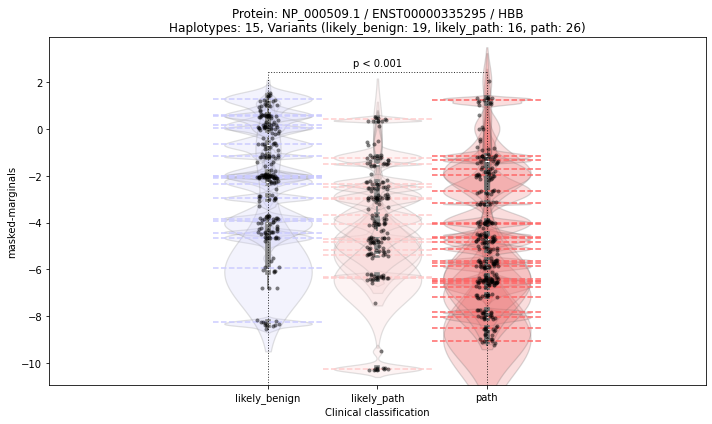

In [82]:
ESM.plot_vep_violin(esm_vep.loc[(esm_vep['protein'] == np_id) & (esm_vep['scoring_strategy'] == "masked-marginals")], 
                    model_location="esm1v_t33_650M_UR90S_1",
                    add_connections=False)

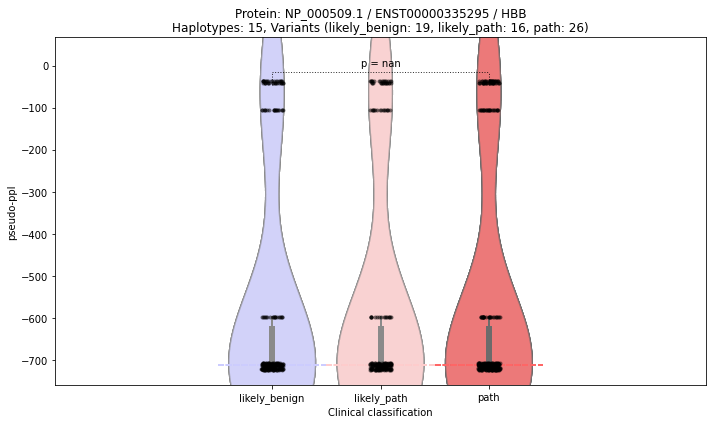

In [83]:
ESM.plot_vep_violin(esm_vep.loc[(esm_vep['protein'] == np_id) & (esm_vep['scoring_strategy'] == "pseudo-ppl")], 
                    model_location="esm1v_t33_650M_UR90S_1",
                    add_connections=False)